# Etapa 2 - Modelado, Entrenamiento, Explicabilidad y Evaluación
## Sistema de Recomendación de Vehículos Usados
**Curso:** Inteligencia Artificial - IC 6200  
**Estudiantes:** Andrés Bonilla Solano y Mary Paz Álvarez Navarrete  
**Dataset:** Used Cars de Austin Reese (Kaggle)  
**Fecha:** 29/05/2026

---

## Índice
1. [Configuración y Reproducibilidad]()
2. [Carga y Preprocesamiento]()
3. [Pipeline de Features]()
4. [Partición Temporal Train / Val / Test]()
5. [Baseline - Regresión Lineal]()
6. [Modelos Candidatos con Validación Cruzada]()
7. [Hypertuning]()
8. [Evaluación Final sobre el Test Set]()
9. [XAI - Explicabilidad con Shap]()


---
## 1. Configuración y Reproducibilidad

Se tiene como objetivo que cualquier persona pueda reproducir exactamente los mismos resultados al ejecutar el cuaderno por lo tanto se establece una seed (`SEED = 42`). Asimismo, se deben instalar las dependencias para que funcione el cuaderno.

In [1]:
# Instalación de dependencias (ejecutar en caso de que no se tengan instalads)
# pip install shap scikit-learn pandas numpy matplotlib seaborn

In [10]:
# Imports generales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random
import os
import time

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
warnings.filterwarnings('ignore')

# sklearn
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import KFold, TimeSeriesSplit, cross_validate, learning_curve
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    mean_absolute_percentage_error, r2_score
)

---

## 2. Carga y Procesamiento



In [3]:
# Cargar datos
df = pd.read_csv('../Dataset/vehicles.csv')
print(f"Cantidad de filas: {df.shape[0]:,}  -  Cantidad de columnas: {df.shape[1]}")

Cantidad de filas: 426,880  -  Cantidad de columnas: 26


In [4]:
# Se eliminan columnas con base en decisiones de la Etapa 1
deleteCols = ['id', 'url', 'region_url', 'image_url', 'VIN', 'lat', 'long', 'county', 'description']
df.drop(columns=deleteCols, inplace=True)
print("Columnas restantes:", df.columns.tolist())

# Filtros de Outliers
df = df[(df['price'].between(500, 100000)) & (df['odometer'].between(100, 500000)) &
    (df['year'].between(1990, 2022))].copy()

print(f"Cantidad de filas: {df.shape[0]:,}  -  Cantidad de columnas: {df.shape[1]}")
print("Columnas restantes:", df.columns.tolist())

Columnas restantes: ['region', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color', 'state', 'posting_date']
Cantidad de filas: 364,546  -  Cantidad de columnas: 17
Columnas restantes: ['region', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color', 'state', 'posting_date']


In [5]:
# Imputación de nulos
# A continuación se tienen las decisiones tomadas en la Etapa 1 con respecto a los nulos.

# size: se elimina porque >71% son nulos
df.drop(columns=['size'], errors='ignore', inplace=True)

# cylinders y condition: imputación por moda agrupada (manufacturer + type)
for col in ['cylinders', 'condition', 'drive']:
    if col in df.columns:
        mode_map = (
            df.dropna(subset=[col])
              .groupby(['manufacturer', 'type'])[col]
              .agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else np.nan)
        )
        for idx, row in df[df[col].isna()].iterrows():
            key = (row.get('manufacturer'), row.get('type'))
            if key in mode_map.index:
                df.at[idx, col] = mode_map[key]

# Agrupación de categorías minoritarias de type (<1%) en "other"
if 'type' in df.columns:
    minor_types = ['offroad', 'bus']
    df['type'] = df['type'].replace(minor_types, 'other')

# El "paint_color se mantiene como opcional 
# Los nulos restantes se manejan en el pipeline con SimpleImputer

print("Nulos restantes por columna (serán manejados en el pipeline):")
print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))

Nulos restantes por columna (serán manejados en el pipeline):
paint_color     103693
type             75691
cylinders        55594
drive            50174
condition        48976
manufacturer     11367
title_status      6059
model             3341
fuel              2064
transmission      1444
dtype: int64


---
## 3. Pipeline de Features

### Calculo del Impacto de otras variables

En la Etapa 1, se obtuvieron los valores para el `year`, `odometer`, `manufacturer` y `fuel`. Por lo tanto, falta calcular el valor del impacto de `condition`,`transmission`,`drive`,`type`,`title_status` y `cylinders`.

Distribución de rangos porcentuales encontrados:
  Mínimo : 63.3%
  P33    : 110.0%  <- umbral Bajo/Medio
  P66    : 129.6%  <- umbral Medio/Alto
  Máximo : 178.6%
Variable           Rango ($)    Rango (%)    Impacto
condition           18,900       159.5%        Alto
transmission        18,591       108.1%        Bajo
drive               11,500        63.3%        Bajo
type                21,090       116.8%       Medio
title_status        16,500       178.6%        Alto
cylinders           22,200       111.0%       Medio


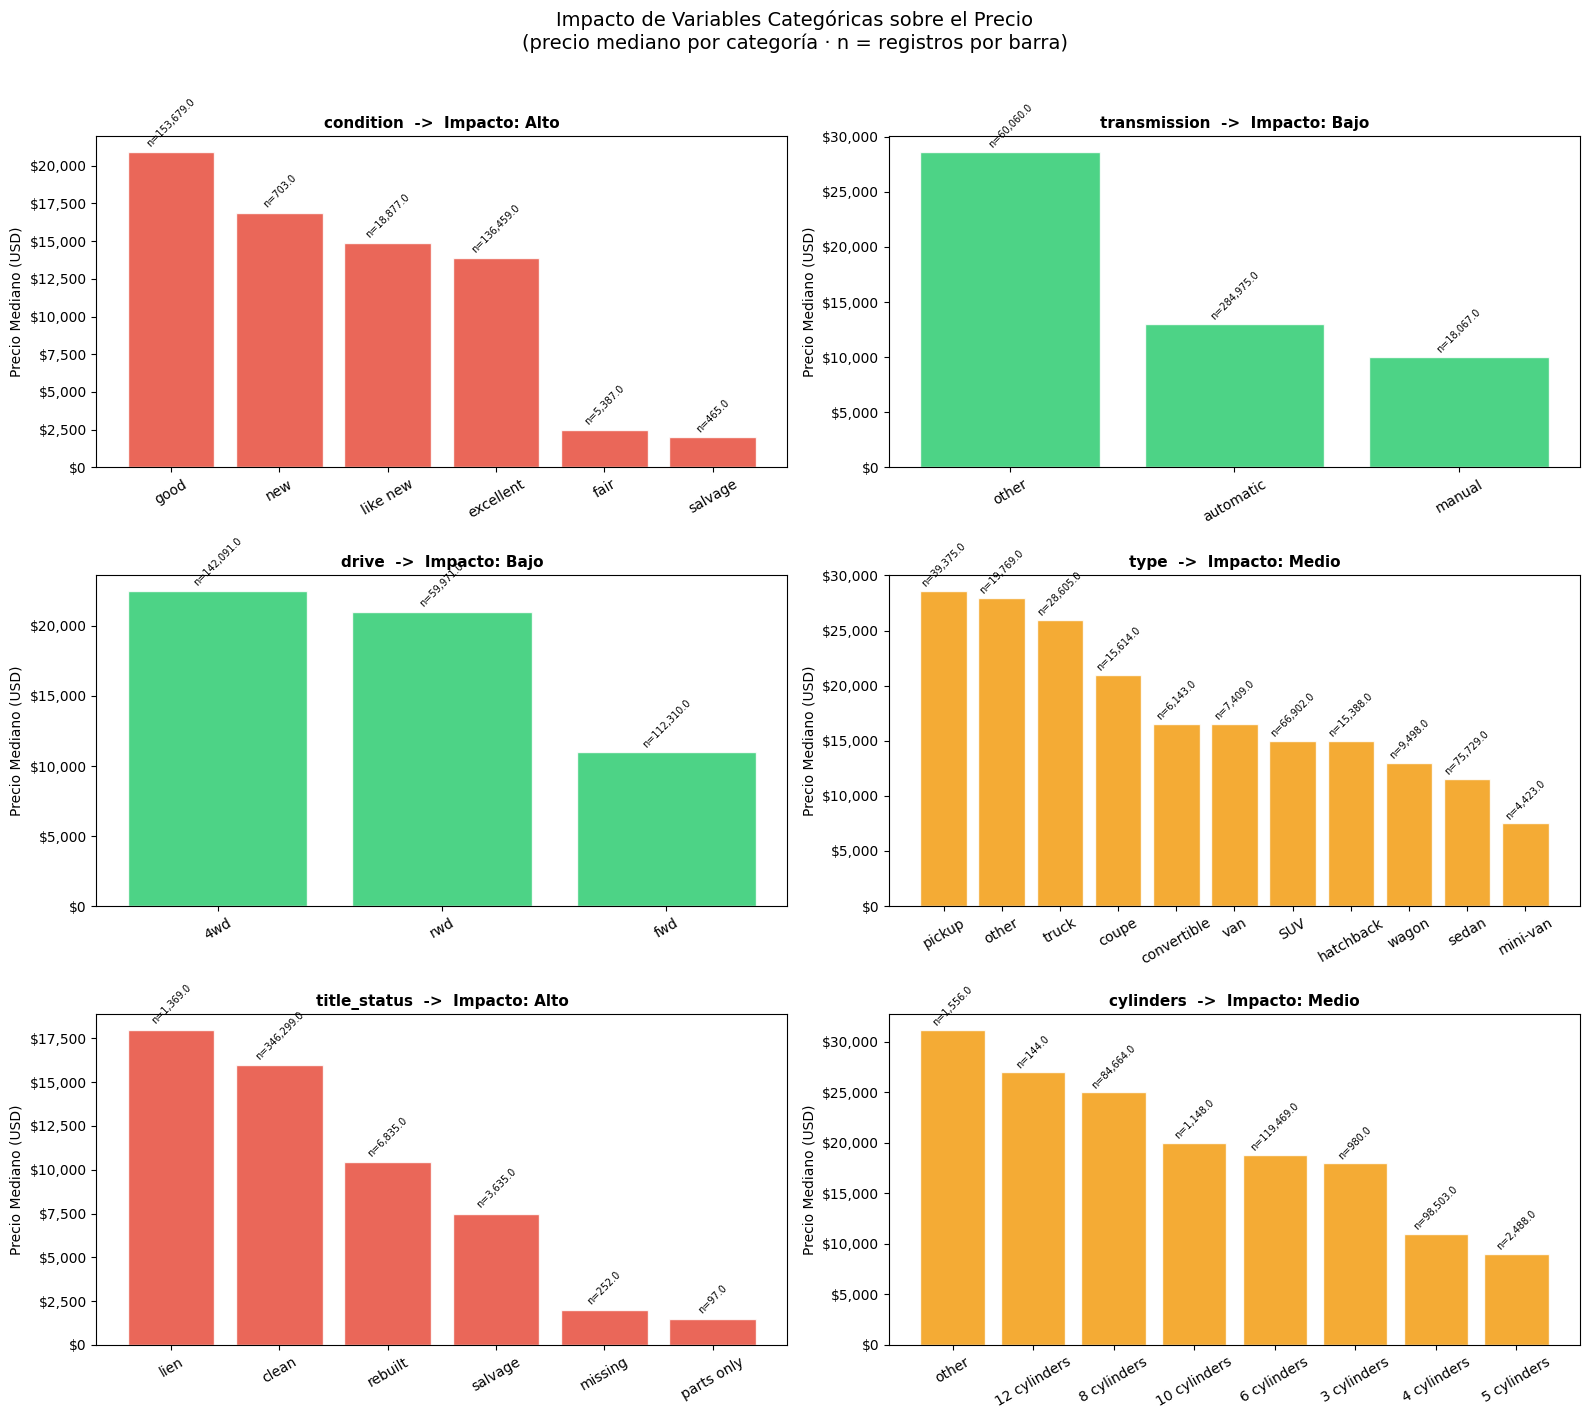

In [6]:
# Cálculo de impacto de variables categóricas sobre el precio 
variables = ['condition', 'transmission', 'drive', 'type', 'title_status', 'cylinders']

# Primra parte: Calcular rangos reales para poder definir umbrales adaptativos 
rangos = []
for col in variables:
    medias = (df.dropna(subset=[col])
                .groupby(col)['price']
                .agg('median')
                .sort_values(ascending=False))
    rango = medias.max() - medias.min()
    rango_porcentual = (rango / medias.mean()) * 100
    rangos.append(rango_porcentual)

p33 = np.percentile(rangos, 33)
p66 = np.percentile(rangos, 66)

print(f"Distribución de rangos porcentuales encontrados:")
print(f"  Mínimo : {min(rangos):.1f}%")
print(f"  P33    : {p33:.1f}%  <- umbral Bajo/Medio")
print(f"  P66    : {p66:.1f}%  <- umbral Medio/Alto")
print(f"  Máximo : {max(rangos):.1f}%")

# Segunda Parte: Tabla resumen 
print(f"{'Variable':<15} {'Rango ($)':>12} {'Rango (%)':>12} {'Impacto':>10}")
print("=" * 60)

impactos_calculados = {}

for col, rango_porcentual in zip(variables, rangos):
    medias = df.dropna(subset=[col]).groupby(col)['price'].agg('median')
    rango_abs = medias.max() - medias.min()

    if rango_porcentual >= p66:
        impacto = "Alto"
    elif rango_porcentual >= p33:
        impacto = "Medio"
    else:
        impacto = "Bajo"

    impactos_calculados[col] = impacto
    print(f"{col:<15} {rango_abs:>10,.0f}  {rango_porcentual:>10.1f}%  {impacto:>10}")

# Tercera Parte: Gráficos 
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

color_map = {'Alto': '#e74c3c', 'Medio': '#f39c12', 'Bajo': '#2ecc71'}

for i, col in enumerate(variables):
    medias = (df.dropna(subset=[col])
                .groupby(col)['price']
                .agg(['median', 'count'])
                .sort_values('median', ascending=False))

    impacto = impactos_calculados[col]
    color = color_map[impacto]

    axes[i].bar(medias.index, medias['median'],
                color=color, alpha=0.85, edgecolor='white')

    for j, (idx, row) in enumerate(medias.iterrows()):
        axes[i].text(j, row['median'] + 200, f"n={row['count']:,}",
                     ha='center', va='bottom', fontsize=7, rotation=45)

    axes[i].set_title(f'{col}  ->  Impacto: {impacto}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Precio Mediano (USD)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'${x:,.0f}')
    )

plt.suptitle(
    'Impacto de Variables Categóricas sobre el Precio\n'
    '(precio mediano por categoría · n = registros por barra)',
    fontsize=14, y=1.01
)
plt.tight_layout()
plt.savefig('impacto_variables_categoricas.png', dpi=150)
plt.show()

### Definición de features

Basado en el análisis de impacto de la Etapa 1, las variables con impacto Alto/Medio son:

| Variable | Tipo | Impacto | Tratamiento |
|---|---|---|---|
| `year` | Numérica | Alto | StandardScaler |
| `odometer` | Numérica | Alto | StandardScaler |
| `manufacturer` | Categórica | Medio | OneHotEncoder |
| `condition` | Categórica | Alto | OrdinalEncoder |
| `fuel` | Categórica | Bajo/Medio | OneHotEncoder |
| `transmission` | Categórica | Bajo | OneHotEncoder |
| `drive` | Categórica | Bajo | OneHotEncoder |
| `type` | Categórica | Medio | OneHotEncoder |
| `title_status` | Categórica | Alto | OneHotEncoder |
| `cylinders` | Categórica | Medio | OrdinalEncoder |

**Variables excluidas:** 
- `description`: data leakage directo (contiene precio explícito)  
- `price`: Es la variable objetivo 
- `posting_date`: solo para partición temporal  
- `region`, `state`: evaluación SHAP pendiente (riesgo leakage geográfico)  
- `model`: Existen miles de valores únicos por lo que se genera un riesgo de overfitting  
- `paint_color`: bajo impacto en precio

In [7]:
# Definición de Features y el Target

TARGET = 'price'

FEATURES_NUMERICAS = ['year', 'odometer']

# Se necesita definir el orden de las variables 'condition' y 'cylinders'

# Condition 
# Tiene orden semántico: salvage < fair < good < excellent < like new < new
CONDITION_ORDER = ['salvage', 'fair', 'good', 'excellent', 'like new', 'new']

# Cylinders 
# Presenta un orden numérico implícito
CYLINDERS_ORDER = ['3 cylinders', '4 cylinders', '5 cylinders',
                   '6 cylinders', '8 cylinders', '10 cylinders', '12 cylinders', 'other']

ORDINAL_FEATURES  = ['condition', 'cylinders']

# Nominal porque no hay un orden o ranking inherente.
NOMINAL_FEATURES  = ['manufacturer', 'fuel', 'transmission', 'drive', 'type', 'title_status']

TODAS_FEATURES = FEATURES_NUMERICAS + ORDINAL_FEATURES + NOMINAL_FEATURES

print(f"Features totales: {len(TODAS_FEATURES)}")
print(f"  Numéricas  : {FEATURES_NUMERICAS}")
print(f"  Ordinales  : {ORDINAL_FEATURES}")
print(f"  Nominales  : {NOMINAL_FEATURES}")
print(f"  Target     : {TARGET}")

Features totales: 10
  Numéricas  : ['year', 'odometer']
  Ordinales  : ['condition', 'cylinders']
  Nominales  : ['manufacturer', 'fuel', 'transmission', 'drive', 'type', 'title_status']
  Target     : price


In [8]:
# Construcción del ColumnTransformer

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # rellena nulos con la mediana
    ('scaler',  StandardScaler()) # Se escalan los valores
])

# El OrdinalEncoder convierte las categorías a números respetando el orden semántico que ya tienen
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # rellena nulos con la moda
    ('encoder', OrdinalEncoder(
        categories=[CONDITION_ORDER, CYLINDERS_ORDER],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # moda
    ('encoder', OneHotEncoder(
        drop='first', # Para evitar multicolinealidad en regresión lineal
        handle_unknown='ignore',
        sparse_output=False
    ))
])

# Aplica las transformaciones a las columnas que les corresponden
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,  FEATURES_NUMERICAS),
    ('ord', ordinal_transformer,  ORDINAL_FEATURES),
    ('nom', nominal_transformer,  NOMINAL_FEATURES)
], remainder='drop')  # Las columnas no listadas se descartan

print("ColumnTransformer construido correctamente.")

ColumnTransformer construido correctamente.


---

# 4. Partición Temporal Train / Val / Test

**Justificación:** Según lo que se detalló en la Sección 3.6 (Riesgo 3) de la primera etapa del proyecto, la partición debe respetar el orden cronológico de `posting_date` para evitar que el modelo entrene con datos del futuro y se evalúe con datos del pasado.

- **70%** registros más antiguos -> **Train**  
- **15%** intermedios -> **Validación** (hypertuning)  
- **15%** más recientes -> **Test** (evaluación final, never touch)

In [9]:
# Partición temporal 
# Se ordena el dataset por la fecha en que fue publicado el anuncio (de más antiguo a más reciente)
df['posting_date'] = pd.to_datetime(df['posting_date'], utc=True, errors='coerce')
df_sorted = df.sort_values('posting_date').reset_index(drop=True)

n = len(df_sorted)
n_train = int(n * 0.70)
n_val = int(n * 0.15)
# el resto (15%) es para el test

# 'iloc' selecciona las filas por posición numérica
df_train = df_sorted.iloc[:n_train]
df_val = df_sorted.iloc[n_train : n_train + n_val]
df_test  = df_sorted.iloc[n_train + n_val:]

X_train = df_train[TODAS_FEATURES] 
y_train = df_train[TARGET] 

X_val = df_val[TODAS_FEATURES]
y_val = df_val[TARGET]

X_test = df_test[TODAS_FEATURES]
y_test = df_test[TARGET]

print("===" * 20)
print(f"Train : {len(X_train):>7,} registros  ({len(X_train)/n*100:.1f}%)")
print(f"Val   : {len(X_val):>7,} registros  ({len(X_val)/n*100:.1f}%)")
print(f"Test  : {len(X_test):>7,} registros  ({len(X_test)/n*100:.1f}%)")
print("===" * 20)
print(f"Rango temporal Train : {df_train['posting_date'].min().date()} -> {df_train['posting_date'].max().date()}")
print(f"Rango temporal Val   : {df_val['posting_date'].min().date()} -> {df_val['posting_date'].max().date()}")
print(f"Rango temporal Test  : {df_test['posting_date'].min().date()} -> {df_test['posting_date'].max().date()}")
print("===" * 20)

Train : 255,182 registros  (70.0%)
Val   :  54,681 registros  (15.0%)
Test  :  54,683 registros  (15.0%)
Rango temporal Train : 2021-04-04 -> 2021-04-30
Rango temporal Val   : 2021-04-30 -> 2021-05-03
Rango temporal Test  : 2021-05-03 -> 2021-05-05


--- 

# 5. Baseline - Regresión Lineal

**Propósito:** Establece cuánto se puede explicar asumiendo relaciones **lineales** entre las features y el precio. Sirve para establecer un punto de referencia para evaluar el rendimiento de modelos más complejos o justificar la necesidad de modelos no-lineales. Este modelo es simple, interpretable y muy bueno para realizar benchmarks.

**Justificación:** La Regresión Lineal es interpretable directamente por sus coeficientes. El EDA mostró que `year` tiene correlación r=0.58 y `odometer` r=-0.54 con `price`, lo que sugiere que una parte significativa de la varianza es captureable linealmente. Sin embargo, el scatter plot mostró una tendencia exponencial, lo que podría significar que hay un limite en la linealidad.

**Técnica de validación:** TimeSeriesSplit(k=5) sobre el train set para estimar la varianza del modelo antes de ver el test set. `TimeSeriesSplit` permite realizar la partición temporal mencionada en la sección anterior.

In [14]:
# Función auxiliar para las métricas
def obtener_metricas(y_true, y_pred, model_name="Modelo"):
    """Calcula y retorna un diccionario con las métricas estándar de regresión."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2 = r2_score(y_true, y_pred)
    metrics = {'Modelo': model_name, 'MAE ($)': mae, 'RMSE ($)': rmse,
               'MAPE (%)': mape, 'R²': r2}
    return metrics

# Para acumular los resultados de todos los modelos:
results_summary = [] 

In [15]:
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor), # Se usa el ColumnTransformer definido anteriormente
    ('regressor',    LinearRegression())
])

# Cross Validation
cv = TimeSeriesSplit(n_splits=5)

# Para el Scoring se usan tres métricas:
# neg_mean_absolute_error -> MAE negado (sklearn minimiza, por eso es negativo)
# neg_root_mean_squared_error -> RMSE negado
# r2 -> coeficiente de determinación
cv_results_lr = cross_validate(
    pipeline_lr, X_train, y_train, cv=cv,
    scoring=['neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2'],
    return_train_score=True, n_jobs=-1 # return_train_score=True calcula métricas también en train para detectar overfitting
)

'''
Se calcula la media y desviación estándar para reportar
el rendimiento promedio y la estabilidad del modelo entre folds.
'''
print("=" * 55)
print("BASELINE - Regresión Lineal (TimeSeriesSplit CV k=5)")
print("=" * 55)
print(f"MAE  CV (val) : ${-cv_results_lr['test_neg_mean_absolute_error'].mean():>10,.2f} ± {cv_results_lr['test_neg_mean_absolute_error'].std():,.2f}")
print(f"RMSE CV (val) : ${-cv_results_lr['test_neg_root_mean_squared_error'].mean():>10,.2f} ± {cv_results_lr['test_neg_root_mean_squared_error'].std():,.2f}")
print(f"R²   CV (val) :  {cv_results_lr['test_r2'].mean():>10.4f} ± {cv_results_lr['test_r2'].std():.4f}")
print("=" * 55)
# Las métricas de train permiten comparar contra las de validación para diagnosticar overfitting
print(f"MAE  CV (train): ${-cv_results_lr['train_neg_mean_absolute_error'].mean():>10,.2f}")
print(f"R²   CV (train):  {cv_results_lr['train_r2'].mean():>10.4f}")
print("=" * 55)


BASELINE - Regresión Lineal (TimeSeriesSplit CV k=5)
MAE  CV (val) : $  5,632.73 ± 37.92
RMSE CV (val) : $  8,165.63 ± 130.60
R²   CV (val) :      0.6703 ± 0.0186
MAE  CV (train): $  5,596.08
R²   CV (train):      0.6872


In [16]:
# Se entrena con el pipeline completo
pipeline_lr.fit(X_train, y_train)

# Se generan las predicciones sobre el val set.
y_pred_lr = pipeline_lr.predict(X_val)

'''
Se calcula MAE, RMSE, MAPE y R² comparando los precios reales (y_val)
contra los precios predichos (y_pred_lr) y se agregan a los resultados.
'''
metrics_lr = obtener_metricas(y_val, y_pred_lr, "Baseline: Regresión Lineal")
results_summary.append(metrics_lr)

# Se imprimen todas las métricas
print("Métricas en Validation Set:")
for k, v in metrics_lr.items():
    if k != 'Modelo':
        print(f"  {k:<12}: {v:>10.2f}")

Métricas en Validation Set:
  MAE ($)     :    5510.31
  RMSE ($)    :    8127.98
  MAPE (%)    :      93.27
  R²          :       0.66


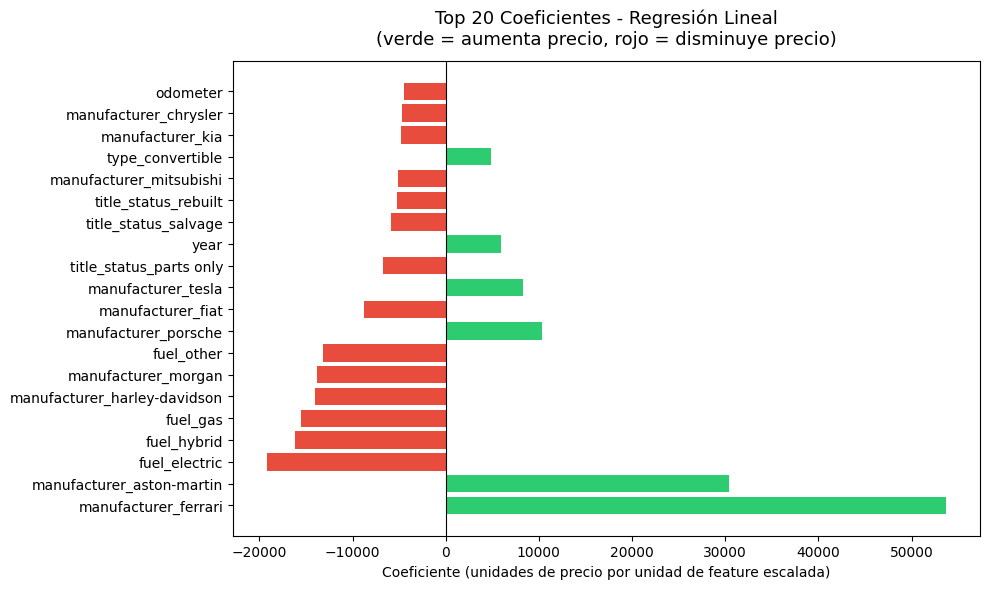


Top 5 features con mayor impacto positivo en el precio:
                  Feature  Coeficiente
     manufacturer_ferrari 53705.491555
manufacturer_aston-martin 30432.584583
     manufacturer_porsche 10326.219789
       manufacturer_tesla  8299.095123
                     year  5954.993292

Top 5 features con mayor impacto negativo en el precio:
                     Feature   Coeficiente
               fuel_electric -19203.657978
                 fuel_hybrid -16190.318588
                    fuel_gas -15541.766763
manufacturer_harley-davidson -14007.455014
         manufacturer_morgan -13848.323808


In [17]:
'''
Los nombres de las features cambian después de la transformación.
Por ejemplo: 'manufacturer' se convierte en múltiples columnas como
'manufacturer_ford', 'manufacturer_chevrolet', etc.
'''

# Las numéricas y ordinales mantienen su nombre original
feature_names_num = FEATURES_NUMERICAS # year y odometer
feature_names_ord = ORDINAL_FEATURES # condition y cylinders

# Ya que se uso OneHotEncoder se expanden las nominales
# Orden en el que se accede: ColumnTransformer -> Transformer nominal -> OneHotEncoder -> Nombres expandidos
feature_names_nom = list(
    pipeline_lr.named_steps['preprocessor']
    .named_transformers_['nom']
    .named_steps['encoder']
    .get_feature_names_out(NOMINAL_FEATURES)
)

all_feature_names = feature_names_num + feature_names_ord + feature_names_nom

# Interpretabilidad:
# DataFrame que relaciona cada feature con su coeficiente.
coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coeficiente': pipeline_lr.named_steps['regressor'].coef_
}).sort_values('Coeficiente', key=abs, ascending=False) # Ordenado por valor absoluto

# Se grafican las 20 features con mayor influencia sobre el precio.
# Verde: coeficiente positivo (la feature aumenta el precio predicho)
# Rojo: coeficiente negativo (la feature disminuye el precio predicho)
fig, ax = plt.subplots(figsize=(10, 6))
top20  = coef_df.head(20)
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in top20['Coeficiente']]
ax.barh(top20['Feature'], top20['Coeficiente'], color=colors)
ax.set_title('Top 20 Coeficientes - Regresión Lineal\n(verde = aumenta precio, rojo = disminuye precio)',
             fontsize=13, pad=12)
ax.set_xlabel('Coeficiente (unidades de precio por unidad de feature escalada)')
# Línea vertical en 0 para ver el cambio de signo
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('coeficientes_regresion_lineal.png', dpi=150)
plt.show()

# Tablas para complementar el gráfico:
print("\nTop 5 features con mayor impacto positivo en el precio:")
print(coef_df[coef_df['Coeficiente'] > 0].head(5).to_string(index=False))
print("\nTop 5 features con mayor impacto negativo en el precio:")
print(coef_df[coef_df['Coeficiente'] < 0].head(5).to_string(index=False))